# Dataset Split Analysis

Inspect how `split_dataset_paths` distributes subjects across **train / validation / test** splits.

Change `SEED` in the next cell and re-run all cells to evaluate a different random split.

In [ ]:
import sys
sys.path.insert(0, '.')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from utils.data_loader import DataLoader
from utils.health_data_loader import HealthDataLoader

## Configuration

Edit `SEED` here and re-run all cells to inspect a different split.

In [10]:
SEED        = 67
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
# TEST_SPLIT is implicit: 1 - TRAIN_SPLIT - VAL_SPLIT

## Create splits

In [ ]:
data_loader = DataLoader(root_path='data/')
meta_loader = HealthDataLoader()

train_pairs, val_pairs, test_pairs = data_loader.split_dataset_paths(
    train_split=TRAIN_SPLIT, val_split=VAL_SPLIT, seed=SEED
)

splits = {'Train': train_pairs, 'Validation': val_pairs, 'Test': test_pairs}

print(f"Seed: {SEED}")
print(f"Train:      {len(train_pairs):>4} subjects  ({len(train_pairs)/703*100:.1f}%)")
print(f"Validation: {len(val_pairs):>4} subjects  ({len(val_pairs)/703*100:.1f}%)")
print(f"Test:       {len(test_pairs):>4} subjects  ({len(test_pairs)/703*100:.1f}%)")
print(f"Total:      {len(train_pairs)+len(val_pairs)+len(test_pairs):>4} subjects")

Seed: 67
Train:       492 subjects  (70.0%)
Validation:  105 subjects  (14.9%)
Test:        106 subjects  (15.1%)
Total:       703 subjects


## Collect metadata for each split

In [12]:
rows = []
for split_name, pairs in splits.items():
    for hunt3_path, _ in pairs:
        meta = meta_loader.get(
            hunt3_path,
            sex=True, age_hunt3=True, age_hunt4=True,
            labeled=True
        )
        if meta is None:
            continue
        rows.append({
            'split':     split_name,
            'sex':       meta['sex'],        # 0 = Male, 1 = Female
            'age_hunt3': meta['age_hunt3'],  # normalised to [0, 1]
            'age_hunt4': meta['age_hunt4'],  # normalised to [0, 1]
        })

df = pd.DataFrame(rows)
df['sex_label'] = df['sex'].map({0: 'Male', 1: 'Female'})
df['split'] = pd.Categorical(df['split'], categories=['Train', 'Validation', 'Test'], ordered=True)
print(f"Metadata loaded for {len(df)} subjects.")

Metadata loaded for 703 subjects.


## Sex distribution — summary table

In [15]:
summary = df.groupby(['split', 'sex_label'], observed=True).size().unstack(fill_value=0)

# Ensure both columns exist even if one sex is missing in a split
for col in ['Male', 'Female']:
    if col not in summary.columns:
        summary[col] = 0

summary['Total']   = summary['Male'] + summary['Female']
summary['% Male']  = (summary['Male']   / summary['Total'] * 100).round(1)
summary['% Female']= (summary['Female'] / summary['Total'] * 100).round(1)

# Overall row
overall = pd.DataFrame({
    'Male':    [summary['Male'].sum()],
    'Female':  [summary['Female'].sum()],
    'Total':   [summary['Total'].sum()],
    '% Male':  [(summary['Male'].sum() / summary['Total'].sum() * 100).round(1)],
    '% Female':[(summary['Female'].sum() / summary['Total'].sum() * 100).round(1)],
}, index=['Overall'])

display(pd.concat([summary, overall]))

,Female,Male,Total,% Male,% Female
Train,263,229,492,46.5,53.5
Validation,55,50,105,47.6,52.4
Test,56,50,106,47.2,52.8
Overall,374,329,703,46.8,53.2


## Sex distribution — bar chart

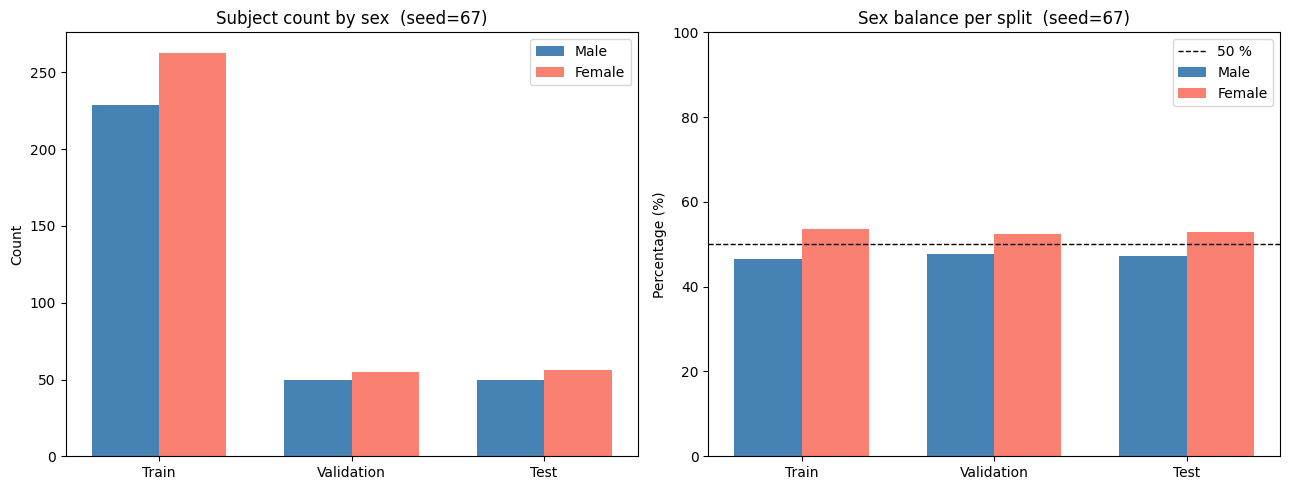

In [16]:
split_names = ['Train', 'Validation', 'Test']
male_pct   = [summary.loc[s, '% Male']   for s in split_names]
female_pct = [summary.loc[s, '% Female'] for s in split_names]

x = np.arange(len(split_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: raw counts ---
ax = axes[0]
ax.bar(x - width/2, [summary.loc[s, 'Male']   for s in split_names], width, label='Male',   color='steelblue')
ax.bar(x + width/2, [summary.loc[s, 'Female'] for s in split_names], width, label='Female', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(split_names)
ax.set_ylabel('Count')
ax.set_title(f'Subject count by sex  (seed={SEED})')
ax.legend()

# --- Right: percentage ---
ax = axes[1]
ax.bar(x - width/2, male_pct,   width, label='Male',   color='steelblue')
ax.bar(x + width/2, female_pct, width, label='Female', color='salmon')
ax.axhline(50, color='black', linestyle='--', linewidth=1, label='50 %')
ax.set_xticks(x)
ax.set_xticklabels(split_names)
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 100)
ax.set_title(f'Sex balance per split  (seed={SEED})')
ax.legend()

plt.tight_layout()
plt.show()

## Age distributions

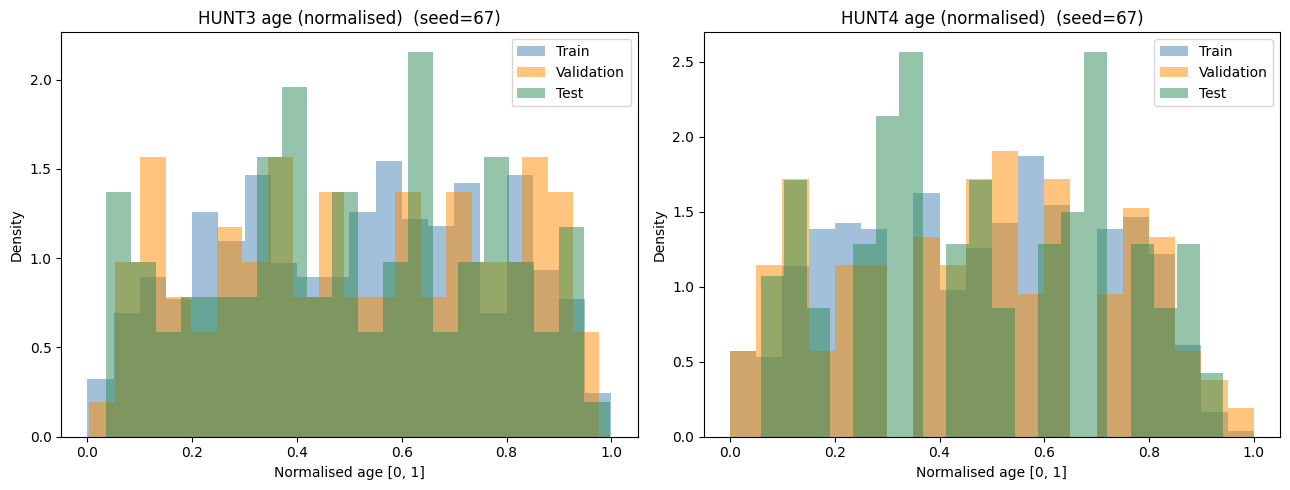

In [17]:
colors = {'Train': 'steelblue', 'Validation': 'darkorange', 'Test': 'seagreen'}
bins = 20

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for split_name in split_names:
    sub = df[df['split'] == split_name]
    axes[0].hist(sub['age_hunt3'], bins=bins, density=True, alpha=0.5,
                 label=split_name, color=colors[split_name])
    axes[1].hist(sub['age_hunt4'], bins=bins, density=True, alpha=0.5,
                 label=split_name, color=colors[split_name])

for ax, title in zip(axes, ['HUNT3 age (normalised)', 'HUNT4 age (normalised)']):
    ax.set_xlabel('Normalised age [0, 1]')
    ax.set_ylabel('Density')
    ax.set_title(f'{title}  (seed={SEED})')
    ax.legend()

plt.tight_layout()
plt.show()

## Age statistics per split

In [18]:
age_stats = df.groupby('split', observed=True)[['age_hunt3', 'age_hunt4']].agg(['mean', 'median', 'std']).round(3)
display(age_stats)

age_hunt3               age_hunt4              
                mean median    std      mean median    std
split                                                     
Train          0.508  0.531  0.254     0.470  0.471  0.246
Validation     0.513  0.516  0.273     0.469  0.471  0.262
Test           0.504  0.493  0.259     0.476  0.471  0.248